# Libraries

In [2]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.signal import find_peaks

# Functions

In [36]:
def K(q, I, z):
    return np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)

def IDF(z, K):
    d1 = np.gradient(K, z)
    return np.gradient(d1, z)

def power(x, k, b):
    return b * x ** k

def porod(x, A):
    return A * x ** -4

def Lorenz(x, y, p = 2):
    return x, y * x ** p

def find_porod_A(x, y):
    const = np.mean(y[-10:])
    best_A = 0.5
    y_sub = y - best_A * const
    
    # Исправленный bounds для одного параметра
    best_p, best_cov = curve_fit(porod, x, y_sub, bounds=(0, np.inf))
    best_cov_val = np.diag(best_cov)[0]  # погрешность первого параметра
    
    # Более мелкий шаг для поиска
    for A in np.arange(0.5, 1.2, 0.01):  # шаг 0.05 вместо 0.1
        y_sub = y - A * const
        try:
            p, cov = curve_fit(porod, x, y_sub, bounds=(0, np.inf))
            current_cov = np.diag(cov)[0]
            
            if current_cov < best_cov_val:
                best_cov_val = current_cov
                best_A = A
                best_p = p
        except:
            continue  # если фит не сошелся
    
    return best_A * const, best_p

def linear(x, k, b):
    return k * x + b

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def corr_analysis(q, I, limits, plot=True, idf=False):
    """
    Анализ SAXS данных для определения структурных параметров
    
    Parameters:
    -----------
    q : array_like
        Вектор рассеяния (nm^-1)
    I : array_like
        Интенсивность рассеяния (a.u.)
    limits : tuple or list
        Границы областей: (left_lim, middle_lim, right_lim)
    plot : bool, default=True
        Рисовать ли графики
    idf : bool, default=False
        Если True, возвращает параметры IDF, иначе параметры корреляционной функции
    
    Returns:
    --------
    Если idf=False:
        z, corr_func, d_amorph_Corr, Lp_cryst_Corr
    Если idf=True:
        z, corr_func, idf_array, d_amorph_idf, d_cryst_idf, d_amorph_idf + d_cryst_idf
    """
    
    left_lim, middle_lim, right_lim = limits
    
    # Поиск индексов границ
    left = np.argmin(np.abs(q - left_lim))
    middle = np.argmin(np.abs(q - middle_lim))
    right = np.argmin(np.abs(q - right_lim))
    
    # Маски для областей
    mask_1 = (q < left_lim)
    mask_2 = (q >= left_lim) & (q < middle_lim)
    mask_3 = (q >= middle_lim) & (q < right_lim)
    
    # Нахождение константы фона и параметров Порода
    x_3 = q[mask_3]
    y_3 = I[mask_3]
    const, p = find_porod_A(x_3, y_3)
    
    # Аппроксимация Порода
    x_porod = np.linspace(middle_lim, 20, 2000)
    y_porod = porod(x_porod, *p)
    
    # Объединение данных
    res_q = np.concatenate([q[mask_2], x_porod])
    res_I = np.concatenate([I[mask_2] - const, y_porod])
    
    if plot:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
        plt.subplots_adjust(wspace=0.4)
        
        # График 1: Исходные данные и аппроксимация
        ax1.loglog(q, I * 2, color='black', alpha=0.5)
        ax1.axvline(x=q[left], color='red', linestyle='--', zorder=2)
        ax1.axvline(x=q[middle], color='red', linestyle='--', zorder=2)
        ax1.axvline(x=q[right], color='red', linestyle='--', zorder=2)
        ax1.plot(q, I - const, alpha=0.5, color='red')
        ax1.plot(x_porod, y_porod, color='black', linestyle='--')
        ax1.loglog(res_q, res_I / 10, color='black', linewidth=2, zorder=100, 
                   label='curve for correlation function')
        ax1.set_xlabel('q (nm$^{-1}$)')
        ax1.set_ylabel('I (a.u.)')
        ax1.legend(loc=3, fontsize=10, framealpha=1)
        
        # График 2: Преобразование Лоренца
        X, Y = Lorenz(res_q, res_I, 2)
        ax2.plot(X, Y, color='black', label='Lorenz')
        ax2.set_xlim(0, right_lim * 1.3)
        ax2.legend(fontsize=10, framealpha=1)
        ax2.set_xlabel('q (nm$^{-1}$)')
        ax2.set_ylabel('I (a.u.)')
    else:
        X, Y = Lorenz(res_q, res_I, 2)
    
    # Вычисление корреляционной функции
    dz = 2 * np.pi / max(X)
    z = np.linspace(dz, 50, int(50 / dz))
    corr_func = K(X, Y, z)  # Здесь K - это функция, не массив!
    corr_func /= max(corr_func)
    
    if idf:
        idf_array = IDF(dz, corr_func)
        
        # Поиск экстремумов IDF
        idf_peaks, _ = find_peaks(idf_array)
        idf_mins, _ = find_peaks(-idf_array)
        
        d_amorph_idf = z[idf_peaks[0]]
        d_cryst_idf = z[idf_peaks[1]]
        Lp_idf = z[idf_mins[0]]
        
        if plot:
            ax3.plot(z, corr_func, color='black', label='K(z)')
            ax3.plot(z, np.zeros(len(z)), linestyle='--', color='black')
            ax3.plot(z, idf_array, color='red', label='IDF(z)')
            ax3.scatter(z[idf_peaks[:2]], idf_array[idf_peaks[:2]], 
                       color='black', marker='s', zorder=0, s=20)
            ax3.scatter(z[idf_mins[1:2]], idf_array[idf_mins[1:2]], 
                       color='black', marker='s', zorder=0, s=20)
            ax3.set_xlabel('z (nm$^{-1}$)')
            ax3.set_ylabel('K & IDF (z)')
            ax3.legend(fontsize=10, framealpha=1)
            ax3.set_ylim(min(corr_func) * 1.1, max(corr_func) * 1.1)
            plt.show()
        
        return z, corr_func, idf_array, d_amorph_idf, d_cryst_idf, d_amorph_idf + d_cryst_idf
    
    else:
        # Поиск экстремумов корреляционной функции
        Corr_peaks, _ = find_peaks(corr_func)
        Corr_mins, _ = find_peaks(-corr_func)
        
        # Линейная аппроксимация для нахождения d_amorph
        def linear(x, a, b):
            return a * x + b
        
        p, _ = curve_fit(linear, z[z < 3], corr_func[z < 3])
        d_amorph_Corr = (corr_func[Corr_mins[0]] - p[1]) / p[0]
        Lp_cryst_Corr = z[Corr_peaks[0]]
        
        if plot:
            ax3.plot(z, corr_func, color='black', label='K(z)')
            ax3.plot(z, np.zeros(len(z)), linestyle='--', color='black')
            ax3.scatter(z[Corr_peaks[0]], corr_func[Corr_peaks[0]], 
                       color='red', marker='s', zorder=0, s=20)
            ax3.scatter(z[Corr_mins[0]], corr_func[Corr_mins[0]], 
                       color='red', marker='s', zorder=0, s=20)
            ax3.plot(z, linear(z, *p), color='red', linestyle='--')
            ax3.plot(z, corr_func[Corr_mins[0]] * np.ones(len(z)), 
                    color='black', linestyle='--')
            ax3.scatter(d_amorph_Corr, linear(d_amorph_Corr, *p), 
                       zorder=10, color='red', marker='s', s=20)
            ax3.set_xlabel('z (nm$^{-1}$)')
            ax3.set_ylabel('K(z)')
            ax3.legend(fontsize=10, framealpha=1)
            ax3.set_ylim(min(corr_func) * 1.1, max(corr_func) * 1.1)
            plt.show()
        
        return z, corr_func, d_amorph_Corr, Lp_cryst_Corr

E:\C390\Autocorrelation function\after_1K_m.dat


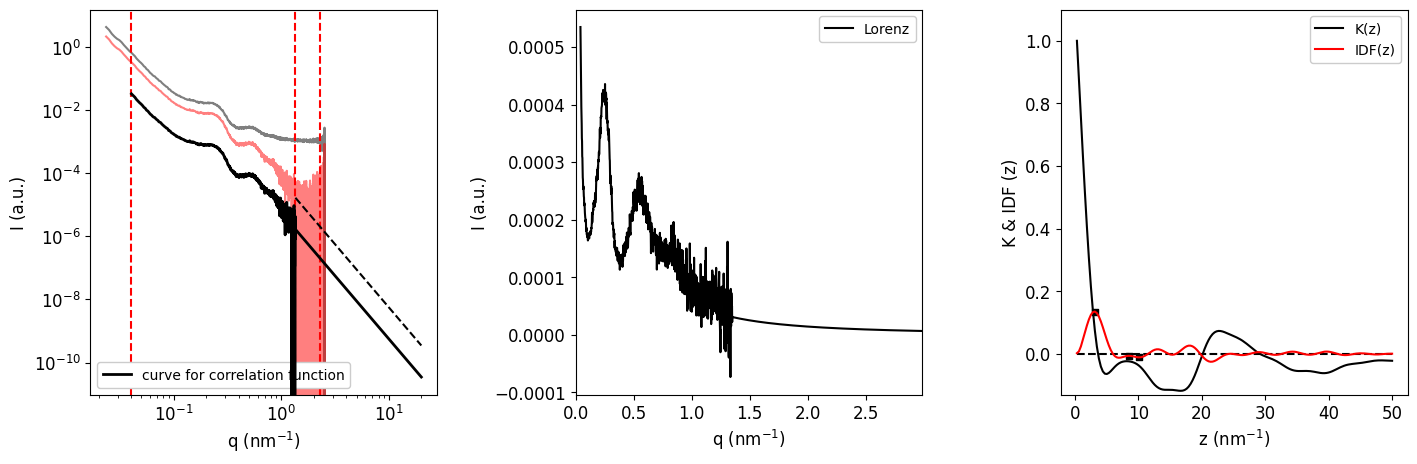

E:\C390\Autocorrelation function\after_1K_s.dat


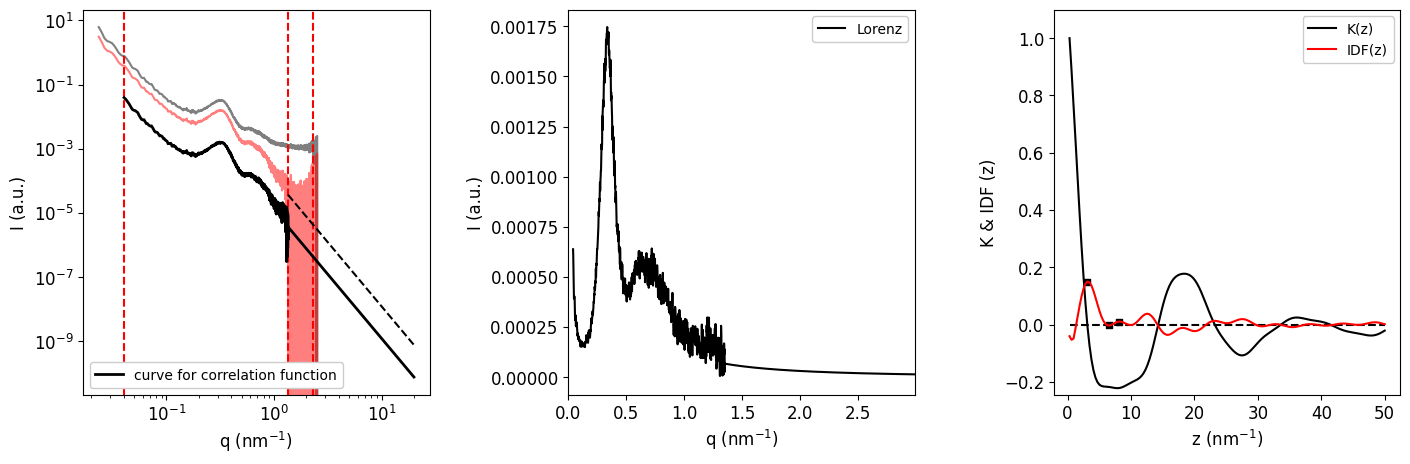

E:\C390\Autocorrelation function\after_5K_s.dat


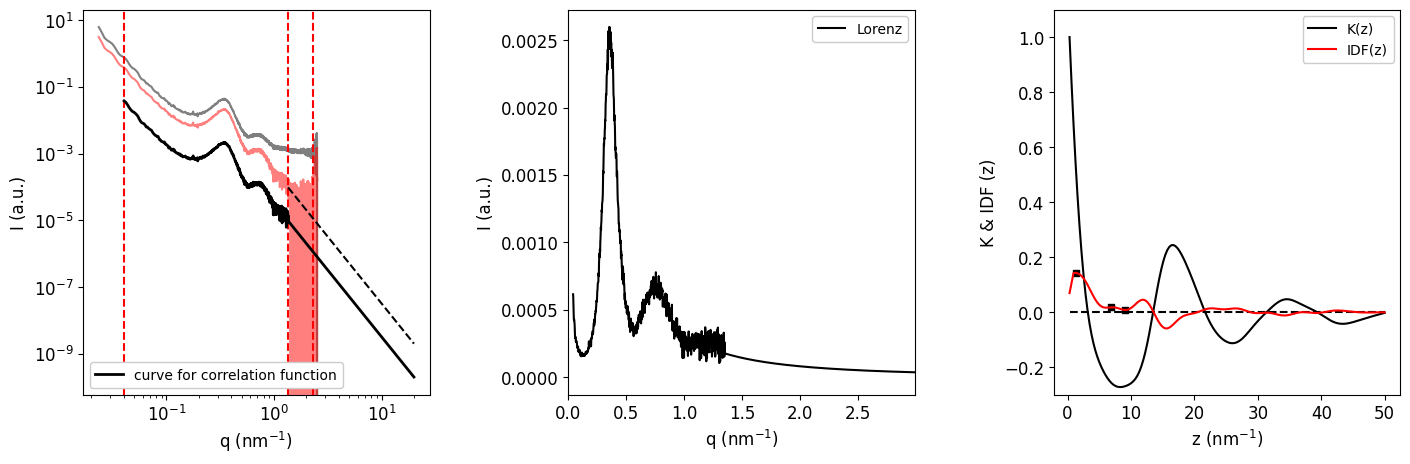

E:\C390\Autocorrelation function\after_10K_s.dat


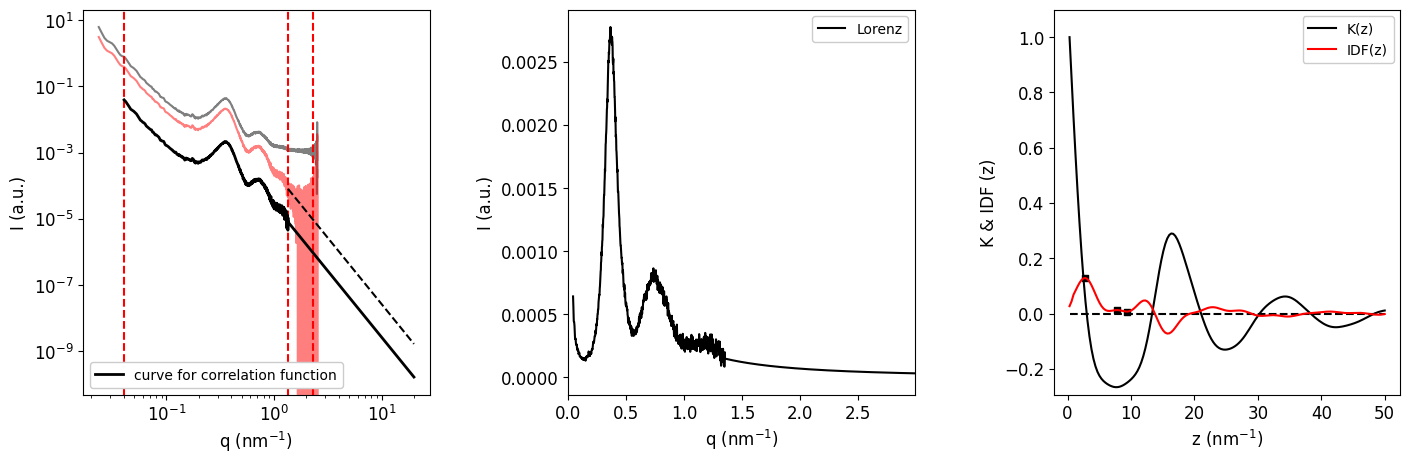

E:\C390\Autocorrelation function\after_20K_m.dat


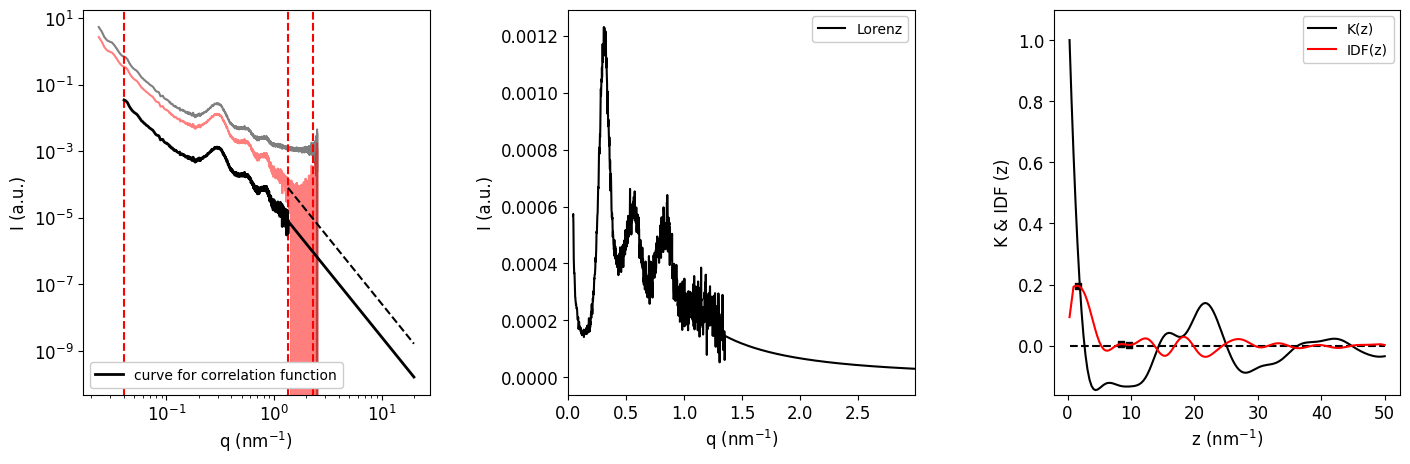

E:\C390\Autocorrelation function\after_100K_s.dat


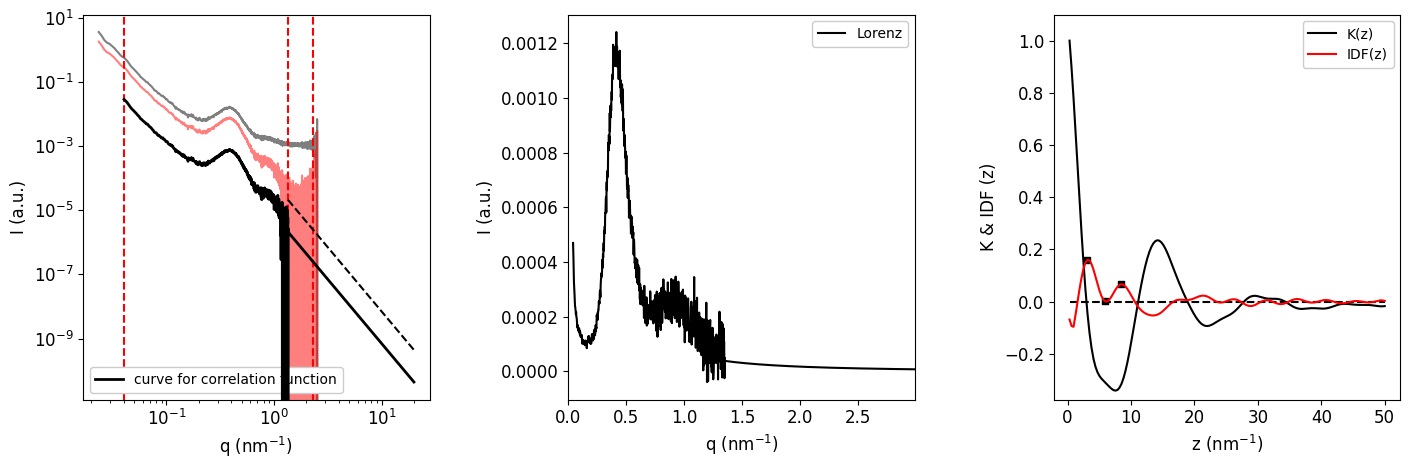

E:\C390\Autocorrelation function\after_1000K_s.dat


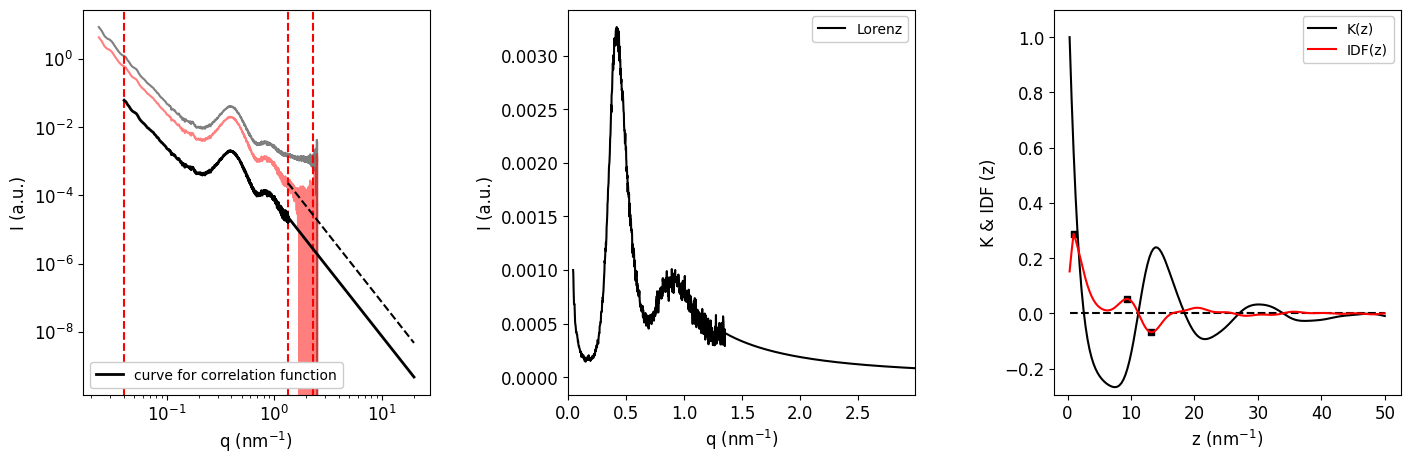

E:\C390\Autocorrelation function\after_quenching.dat


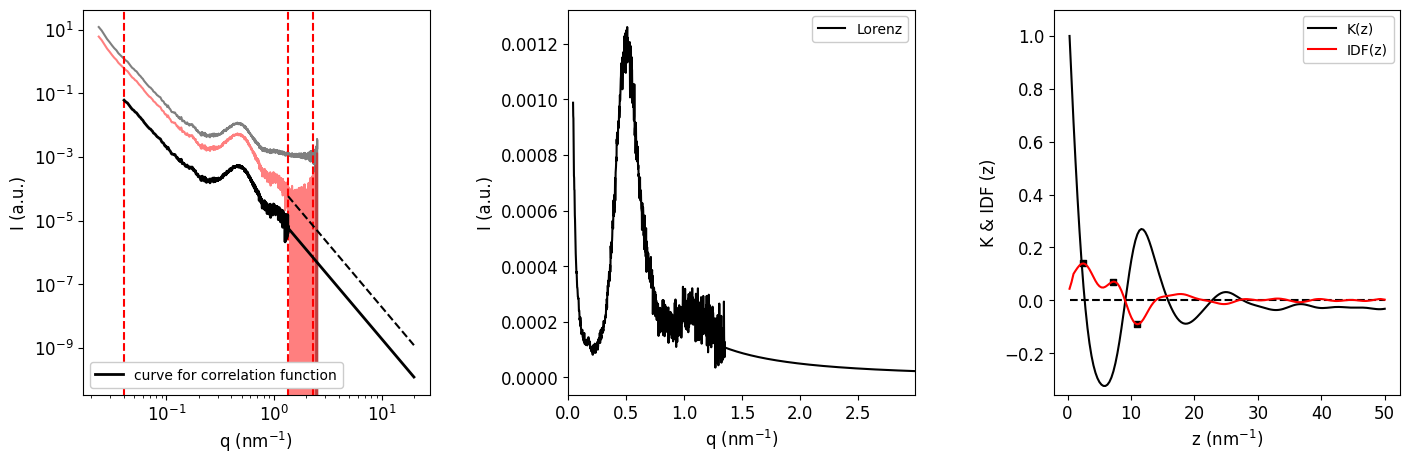

In [43]:
paths = [
    r"E:\C390\Autocorrelation function\after_1K_m.dat",
    r"E:\C390\Autocorrelation function\after_1K_s.dat",
    r"E:\C390\Autocorrelation function\after_5K_s.dat",
    r"E:\C390\Autocorrelation function\after_10K_s.dat",
    r"E:\C390\Autocorrelation function\after_20K_m.dat", 
    r"E:\C390\Autocorrelation function\after_100K_s.dat", 
    r"E:\C390\Autocorrelation function\after_1000K_s.dat",
    r"E:\C390\Autocorrelation function\after_quenching.dat"
]

for path in paths:
    print(path)
    df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
    q, I = np.array(df['q']), np.array(df['I'])
    z, Korr, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, I, limits=(0.04, 1.35, 2.3), 
                                                                plot=True, idf=True)

TypeError: 'numpy.ndarray' object is not callable

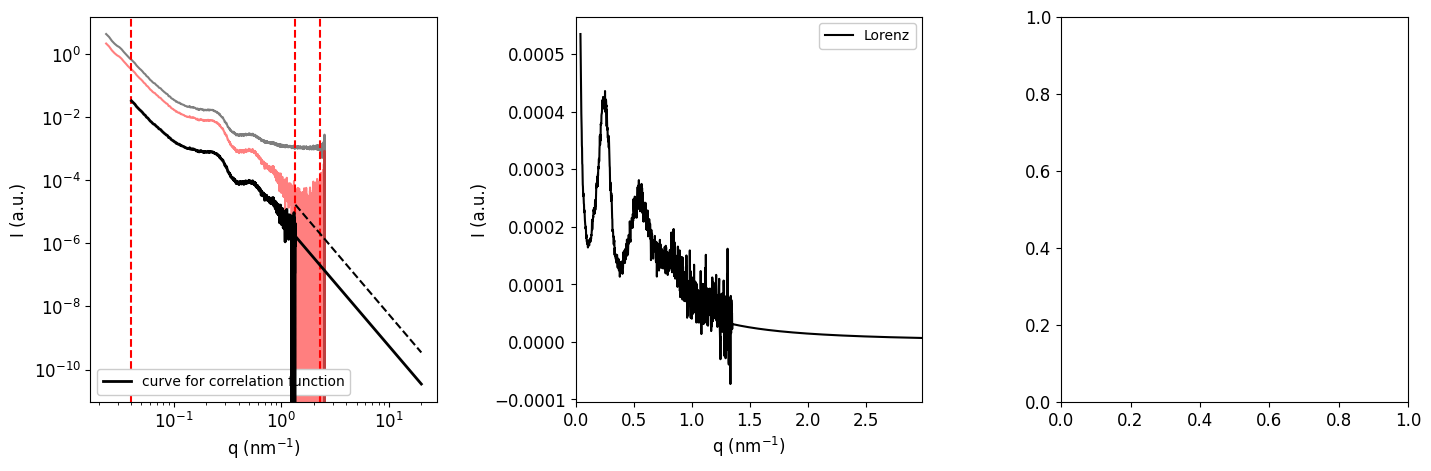

In [29]:
z, K, idf, d_amorph_idf, d_cryst_idf, sum_idf = corr_analysis(q, I, limits=(0.04, 1.35, 2.3), 
                                                                plot=True, idf=True)

# Results

3.4747421123807607
12.263918429386566
2.829898036733208
7.861375579481665
10.691273616214874
5.660104154529216


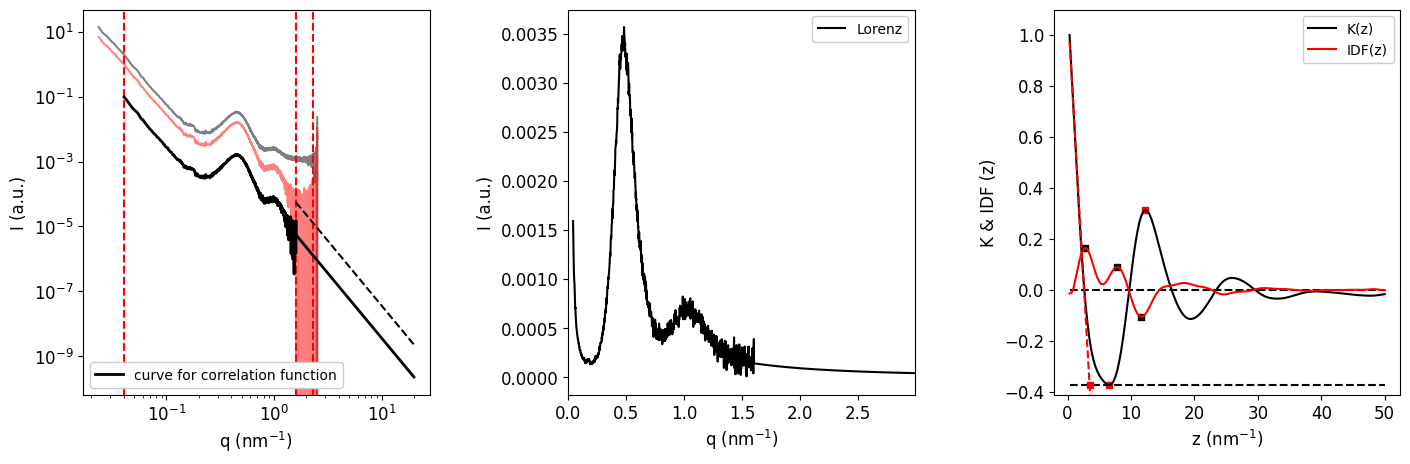

In [62]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17,5))
plt.subplots_adjust(wspace=0.4)
ax1.loglog(q, I * 2, color='black', alpha=0.5) 

left_lim = 0.04
middle_lim = 1.6
right_lim = 2.3

left = np.argmin(np.abs(q - left_lim))
middle = np.argmin(np.abs(q - middle_lim))
right = np.argmin(np.abs(q - right_lim))

ax1.axvline(x=q[left], color='red', linestyle='--', zorder=2)
ax1.axvline(x=q[middle], color='red', linestyle='--', zorder=2)
ax1.axvline(x=q[right], color='red', linestyle='--', zorder=2)

mask_1 = (q < left_lim)
mask_2 = (q >= left_lim) & (q < middle_lim)  # Исправлено: & вместо *
mask_3 = (q >= middle_lim) & (q < right_lim)  # Исправлено: & вместо *
x_3 = q[mask_3]
y_3 = I[mask_3]

const, p = find_porod_A(x_3, y_3)
ax1.plot(q, I - const, alpha = 0.5, color='red')
x_porod = np.linspace(middle_lim, 20, 2000)
y_porod = porod(x_porod, *p)  # Исправлено: распаковка p
ax1.plot(x_porod, y_porod, color='black', linestyle='--')

# ИСПРАВЛЕНО: объединение массивов
res_q = np.concatenate([q[mask_2], x_porod])  # список массивов
res_I = np.concatenate([I[mask_2] - const, y_porod])  # список массивов

ax1.loglog(res_q, res_I / 10, color='black', linewidth=2, zorder=100, label = 'curve for correlation function')

ax1.set_xlabel('q (nm$^{-1}$)')
ax1.set_ylabel('I (a.u.)')
ax1.legend(loc=3, fontsize=(10), framealpha=1)

X, Y = Lorenz(res_q, res_I, 2.) 
ax2.plot(X, Y, color='black', label='Lorenz')
ax2.set_xlim(0, right_lim * 1.3)
ax2.legend(fontsize=(10), framealpha=1)
ax2.set_xlabel('q (nm$^{-1}$)')
ax2.set_ylabel('I (a.u.)')

dz = 2 * np.pi / max(X)
z = np.linspace(dz, 50, int(50 / dz))
Corr = K(X,Y, z)
Corr /= max(Corr)
idf = IDF(dz, Corr)

ax3.plot(z, Corr, color='black', label='K(z)')
ax3.plot(z, np.zeros(len(z)), linestyle='--', color='black')
ax3.plot(z, idf, color='red', label='IDF(z)')
ax3.set_xlabel('z (nm$^{-1}$)')
ax3.set_ylabel('K & IDF (z)')

Corr_peaks, properties = find_peaks(Corr)
Corr_mins, properties = find_peaks(-Corr)
ax3.scatter(z[Corr_peaks[0]], Corr[Corr_peaks[0]], color='red', marker='s', zorder=0, s=20)
ax3.scatter(z[Corr_mins[0]], Corr[Corr_mins[0]], color='red', marker='s', zorder=0, s=20)

p, cov = curve_fit(linear, z[z < 3], Corr[z < 3])

d_amorph_Corr = (Corr[Corr_mins[0]] - p[1]) / p[0]
Lp_cryst_Corr = z[Corr_peaks[0]]
ax3.plot(z, linear(z, *p), color='red', linestyle='--' )
ax3.plot(z, Corr[Corr_mins[0]] * np.ones(len(z)), color='black', linestyle='--' )
ax3.scatter(d_amorph_Corr, linear(d_amorph_Corr, *p), zorder=10, color='red', marker='s', s=20)

idf_peaks, properties = find_peaks(idf)
idf_mins, properties = find_peaks(-idf)
ax3.scatter(z[idf_peaks[:2]], idf[idf_peaks[:2]], color='black', marker='s', zorder=0, s=20)
ax3.scatter(z[idf_mins[1:2]], idf[idf_mins[1:2]], color='black', marker='s', zorder=0, s=20)

ax3.legend(fontsize=(10), framealpha=1)
ax3.set_ylim((min(Corr) * 1.1), (max(Corr) * 1.1))

d_amorph_idf = z[idf_peaks[0]]
d_cryst_idf = z[idf_peaks[1]]
Lp_idf = z[idf_mins[0]]

print(d_amorph_Corr)
print(Lp_cryst_Corr)
print(d_amorph_idf)
print(d_cryst_idf)
print(d_cryst_idf + d_amorph_idf)
print(Lp_idf)

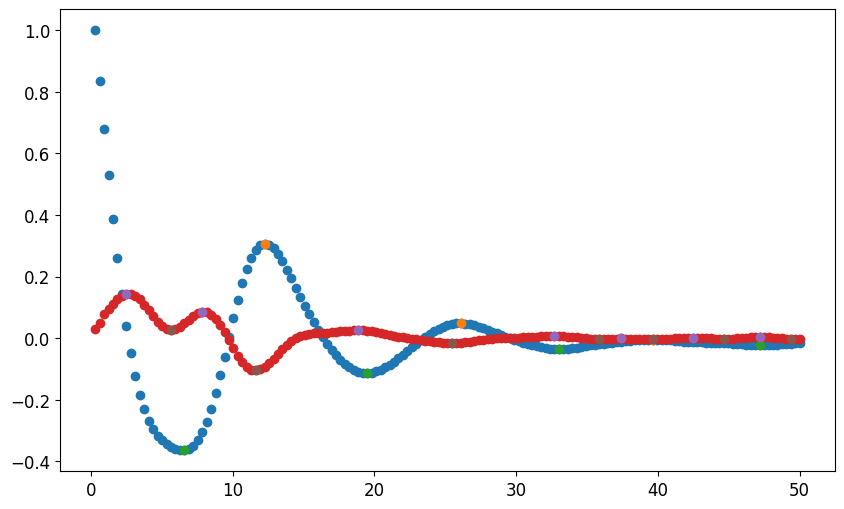

In [291]:
from scipy.signal import find_peaks

plt.scatter(z, Corr)
peaks, properties = find_peaks(Corr)
mins, properties = find_peaks(-Corr)

plt.scatter(z[peaks], Corr[peaks])
plt.scatter(z[mins], Corr[mins])


plt.scatter(z, idf)
peaks, properties = find_peaks(idf)
mins, properties = find_peaks(-idf)

plt.scatter(z[peaks], idf[peaks])
plt.scatter(z[mins], idf[mins])

In [131]:
def gamma1(q, I, r):
    """Корреляционная функция γ₁(r) без нормировки: ∫ I(q) q² cos(qr) dq"""
    return np.array([np.trapz(I * q**2 * np.cos(q * ri), q) for ri in r])

def Gamma(q, I, z):
    K = np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)
    return K

In [121]:
def power(x, k, b):
    return b * x ** k
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d

def sub_const(ax, q, I, lim):
    ax.plot(q, I, color='black', alpha=0.5)
    ax.axvline(x = lim, linewidth=0.5, linestyle='--', color='red')
    mask = q < lim

    x, y = q[mask], (I[mask] - 0.85 * I[mask][-1])
    ax.plot(x,y, color='black', alpha=1)
    return x, y

def sub_power(ax, q, I, lim, A):
    mask = q < lim

    p, cov = curve_fit(power, q[mask], I[mask])

    ax.plot(q[mask],  A * power(q[mask], *p), linestyle='--', color='red')
    x, y = q, I - A * power(q, *p)
    ax.axvline(x = lim, linewidth=0.5, linestyle='--', color='red')
    
    return x, y 
    
def add_porod(ax, x, y, lim, A):
    x_porod = np.linspace(lim, 10, 1000)
    y_porod = x_porod ** -4
    y_porod /= y_porod[0]
    y_porod *= np.mean(y[-10:-1]) / A

    ax.plot(x_porod, y_porod,  alpha = 1, color='black')

    q_full = np.concatenate([x, x_porod])
    I_full = np.concatenate([y, y_porod])

    return q_full, I_full 

def Lorenz(x, y, p = 2):
    return x, y * x ** p

# Data

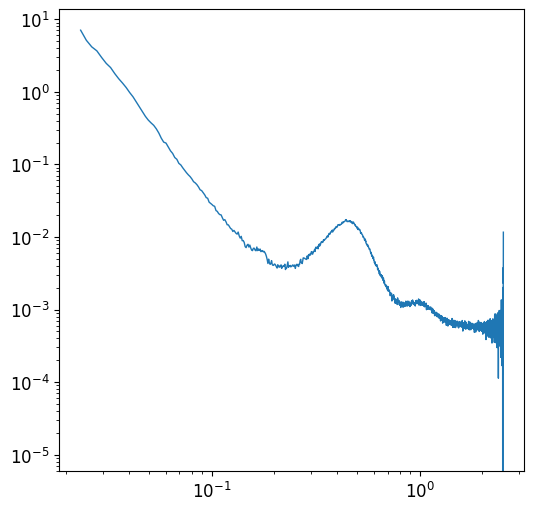

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I, label='after quenching', linewidth=1)
ax.set_xscale('log')
ax.set_yscale('log')


L_p =  12.315043202071989
d =  8.919301749747085
Cr =  0.7242606951022652


(-1.1, 1.1)

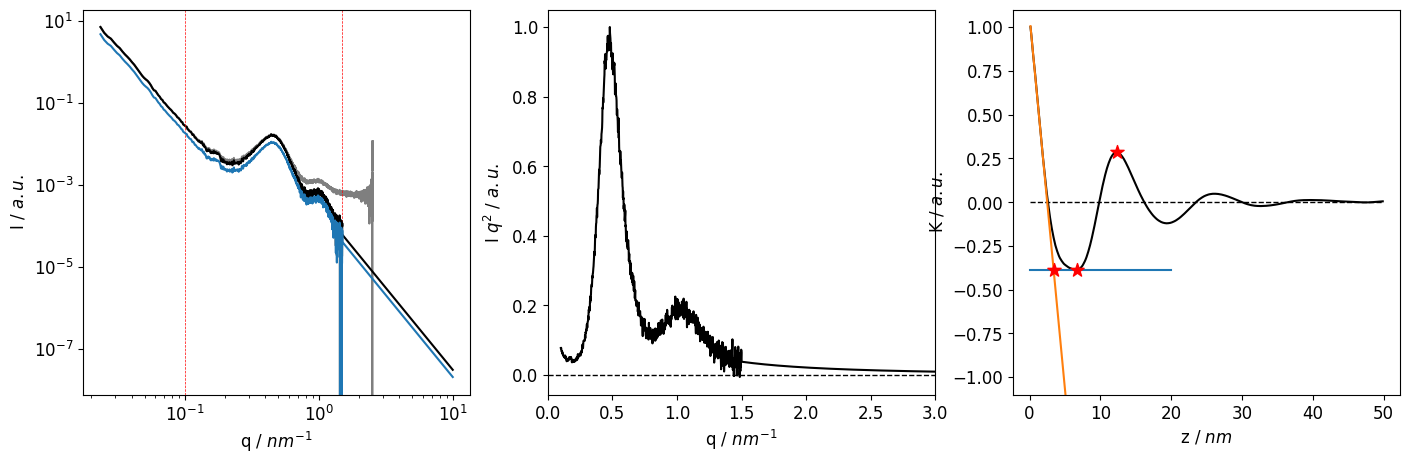

In [150]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17,5))

size= 100
right = 1.5
left = 0.1
lorenz_power = 2

x, y = sub_const(ax1, q, I, right)
x, y = sub_power(ax1, x, y, left, 0.)
x_full, y_full = add_porod(ax1, x, y, right, 1)
ax1.plot(x_full, y_full / 1.5)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('q / $nm^{-1}$')
ax1.set_ylabel('I / $a. u.$')

mask = (x_full > left) 
X, Y = Lorenz(x_full[mask], y_full[mask], p = lorenz_power)

ax2.plot(X, Y / max(Y), label='Lorenz', color='black')
ax2.set_xlim(0, 3)
lnsp = np.linspace(0, max(X))
ax2.plot(lnsp, lnsp * 0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('q / $nm^{-1}$')
ax2.set_ylabel('I $q^2$ / $a. u.$')

z, K = corr_func(X, Y, res = 5, zmax=50)
K /= max(K)
ax3.plot(z, K, color='black')
ax3.plot(z, z * 0, color='black', linewidth=1, linestyle='--')
ax3.set_xlabel('z / $nm$')
ax3.set_ylabel('K / $a. u.$')

mask_max = (z > 7) & (z < 40)
i_max = np.argmax(K[mask_max])
z_max = z[mask_max][i_max]
K_max = K[mask_max][i_max]
ax3.scatter(z_max, K_max, zorder=10, color='red', marker='*', s=size)
print('L_p = ', z_max)

mask_min = (z > 0) & (z < 20)
i_min = np.argmin(K[mask_min])
z_min = z[mask_min][i_min]
K_min = K[mask_min][i_min]
ax3.scatter(z_min, K_min, zorder=10, color='red', marker='*', s=size)

ax3.plot(z[mask_min], K_min * np.ones(len(z[mask_min])))

mask_linear = z < 2
p, cov = curve_fit(linear, z[mask_linear], K[mask_linear])

ax3.plot(z[mask_min], linear(z[mask_min], *p))


z_d = (K_min - p[1]) / p[0]
ax3.scatter(z_d, linear(z_d, *p), zorder=10, color='red', marker='*', s=size)
print('d = ', z_max - z_d)
print('Cr = ', 1 - z_d / z_max)

ax3.set_ylim(-1.1, 1.1)

Text(0, 0.5, 'I (a.u.)')

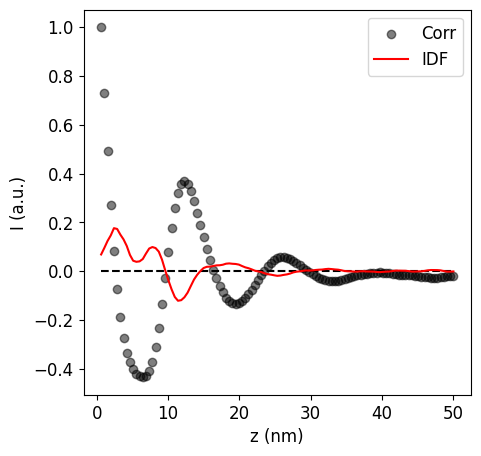

In [259]:
plt.figure(figsize=(5,5))

dz = 2 * pi / max(X)
z = np.linspace(dz, 50, int(70 / dz))
Corr = Gamma(X,Y,z) 
Corr /= Corr[0]
plt.scatter(z, Corr, color='black', alpha=0.5, label='Corr')


d1 = np.gradient(Corr, z)
d2 = np.gradient(d1, z)
IDF = np.gradient(np.gradient(Corr, z), z)
plt.plot(z, IDF, label='IDF', zorder=20, color='red')

plt.plot(z, np.zeros(len(z)), linestyle='--', color='black')

plt.legend()
plt.xlabel('z (nm)')
plt.ylabel('I (a.u.)')

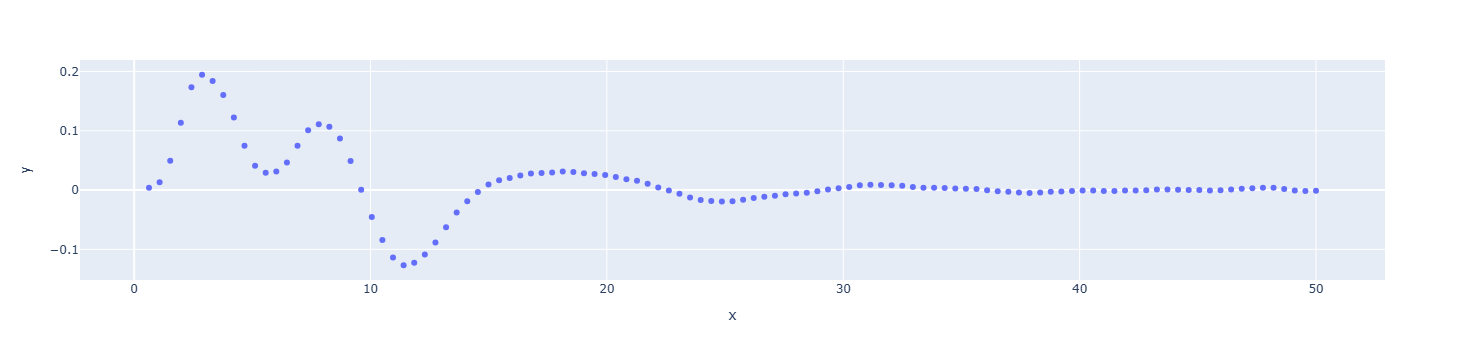

In [145]:
px.scatter(x = z, y = IDF)

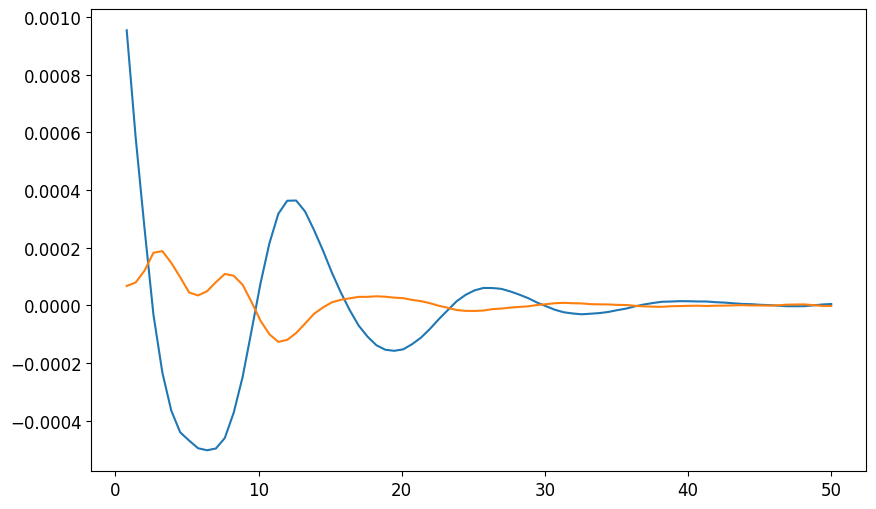

In [102]:
dz = 2 * np.pi / max(X) 

# Ваши данные
z = np.linspace(0.5 * dz, 50, 80)
Corr = Gamma(X,Y, z)

plt.plot(z, Corr)


# Вторая производная от сглаженной
d2 = np.gradient(np.gradient(Corr, z), z)

plt.plot(z, d2, label=f'sigma={sigma}')